##  1. Caricamento del dataset completo

In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.cluster import KMeans








import warnings
warnings.filterwarnings("ignore")

In [2]:
# Carichiamo il dataset originale utilizzato per l'analisi
df = pd.read_excel("../data/dataset_campania.xlsx")

# Visualizziamo le prime righe per confermare caricamento corretto
df.head() 

,Provincia,Codice,Comune,lat,lon,superficie_kmq,Popolazione_2024,Popolazione_per_kmq,Totale_Impianti,Totale_Potenza_kW,...,Altimetria_media,%Pianura,%Collina,%Montagna,contribuenti,reddito_totale,reddito_medio,numero_progetti,finanziamento_totale,presenza_progetto
0,Salerno,65001,ACERNO,40.738214,15.059361,72.1395,2517,34.890733,6,18.17,...,1007.596655,0.000000,49.240335,50.759665,1845,22125115,11991.932249,1,68359,1
1,Napoli,63001,ACERRA,40.948846,14.371327,54.6876,58507,1069.840329,240,6535.81,...,0.000000,100.000000,0.000000,0.000000,30626,533870875,17431.949161,13,33518976,1
2,Napoli,63002,AFRAGOLA,40.922726,14.310427,17.8295,61713,3461.286071,100,834.32,...,0.000000,100.000000,0.000000,0.000000,28687,476853445,16622.632028,4,1211046,1
3,Napoli,63003,AGEROLA,40.637951,14.544835,20.3822,7744,379.939359,26,244.70,...,780.003227,0.000000,71.999677,28.000323,4800,80037550,16674.489583,7,463404,1
4,Salerno,65002,AGROPOLI,40.349679,14.991929,32.5930,21378,655.907710,261,3336.27,...,3.052168,99.389566,0.610434,0.000000,13642,256280065,18786.106509,13,604284,1


## 2. Regressione OLS completa

In [3]:


# Escludiamo le colonne 'Comune', 'Provincia', 'Totale_Potenza_kW' dalle variabili esplicative
X_clean = df.drop(columns=['Comune', 'Provincia', 'Totale_Potenza_kW'])

# Aggiungiamo la costante al modello
X_clean = sm.add_constant(X_clean)

# Target: Totale_Potenza_kW
y_totale_potenza = df['Totale_Potenza_kW']

# Lanciamo il modello OLS
modello_ols = sm.OLS(y_totale_potenza, X_clean).fit()

# Visualizziamo i risultati
modello_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Totale_Potenza_kW   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     114.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.01e-205
Time:                        18:40:08   Log-Likelihood:                -4698.2
No. Observations:                 544   AIC:                             9458.
Df Residuals:                     513   BIC:                             9592.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.4985      3.408     -0.146      0.884      -7.193       6.196
Codice                             0.0931      0.092      1.008      0.314      -0.088       0.274
lat                              -47.4770    424.988     -0.112      0.911    -882.408     787.454
lon                             -495.6048    346.985     -1.428      0.154   -1177.291     186.081
superficie_kmq                     6.9110      4.382      1.577      0.115      -1.698      15.521
Popolazione_2024                   0.1023      0.092      1.109      0.268      -0.079       0.283
Popolazione_per_kmq               -0.0013      0.077     -0.017      0.987      -0.153       0.150
Totale_Impianti                   49.7884      5.870      8.483      0.000      38.257      61.320
0-10 kW                          -25.1934      7.021     -3.588      0.000     -38.987     -11.399
10-30 kW                         -35.5463     14.536     -2.445      0.015     -64.104      -6.988
>30 kW                           110.5281     17.825      6.201      0.000      75.508     145.548
Potenza_per_kmq                    2.3210      0.648      3.584      0.000       1.049       3.593
Impianti_per_kmq                 -48.5759     21.114     -2.301      0.022     -90.057      -7.095
Potenza_media_per_impianto        40.1460      6.655      6.032      0.000      27.071      53.221
Impianti_per_1000_abitanti       139.5401    210.046      0.664      0.507    -273.116     552.196
Potenza_per_1000_abitanti         31.8236      7.413      4.293      0.000      17.260      46.388
Impianti_per_1000_adulti         -41.8567     98.939     -0.423      0.672    -236.232     152.519
Potenza_per_kW_adulti            -15.4570      3.307     -4.673      0.000     -21.955      -8.959
Potenza_per_kW_anziani            -0.6997      0.390     -1.792      0.074      -1.467       0.067
Impianti_per_1000_anziani        -21.5310     11.704     -1.840      0.066     -44.524       1.462
Pop_0_24                           0.4778      0.308      1.552      0.121      -0.127       1.083
Pop_25_64                         -0.0478      0.291     -0.164      0.870      -0.620       0.524
Pop_65_plus                       -0.3277      0.191     -1.713      0.087      -0.703       0.048
Indice_dipendenza                 29.9743     17.016      1.762      0.079      -3.456      63.404
Irraggiamento annuale [kWh/m2]     1.8503      2.053      0.901      0.368      -2.184       5.884
Altimetria_media                  -2.6307     19.338     -0.136      0.892     -40.622      35.361
%Pianura                         -36.8521    242.020     -0.152      0.879    -512.324     438.620
%Collina                         -19.2304    146.199     -0.132      0.895    -306.453     267.992
%Montagna     

#### COMMENTO:

 Il modello OLS costruito sulla variabile 'Totale_Potenza_kW' presenta un R² pari a 0.870,
 indicando che il modello spiega circa l'87% della variabilità della potenza installata.
 Si tratta di un risultato molto elevato, che suggerisce una buona capacità esplicativa del modello.

 Il valore dell'F-statistic (114.2) e la probabilità associata praticamente nulla
 indicano che il modello è complessivamente significativo: le variabili esplicative,
 considerate nel loro insieme, contribuiscono in modo rilevante alla previsione
 della potenza totale installata.

 Tra le variabili statisticamente significative emergono soprattutto:
 - 'Totale_Impianti', con effetto positivo sulla potenza installata;
 - le classi dimensionali degli impianti ('0-10 kW', '10-30 kW', '>30 kW'),
   che mostrano una relazione significativa con la variabile dipendente;
 - indicatori di intensità fotovoltaica come 'Potenza_per_kmq',
   'Impianti_per_kmq', 'Potenza_media_per_impianto' e 'Potenza_per_1000_abitanti';
 - variabili economico-progettuali come 'contribuenti', 'reddito_totale',
   'numero_progetti' e 'presenza_progetto'.

 In particolare, 'numero_progetti' e 'Totale_Impianti' mostrano un effetto positivo,
 mentre 'presenza_progetto' e 'contribuenti' presentano coefficienti negativi.
 Questo suggerisce che alcuni fattori progettuali e territoriali incidono in modo
 differenziato sulla distribuzione della potenza installata.

 Diverse altre variabili risultano invece non statisticamente significative
 (ad esempio coordinate geografiche, alcune variabili demografiche, altimetria,
 uso del suolo e parte degli indicatori territoriali), segnalando che non tutte
 contribuiscono in modo autonomo alla spiegazione della potenza totale installata.

 La multicollinearità appare molto elevata, come suggerito dal condition number
 pari a 2.13e+17 e dall'autovalore minimo molto piccolo. Questo indica che alcune
 variabili sono fortemente correlate tra loro, rendendo il modello OLS instabile
 in alcune stime e suggerendo l'utilità di modelli penalizzati come Ridge e Lasso.

 Prossimi passi:
 1. Confrontare i risultati con modelli penalizzati (Ridge e Lasso);
 2. Valutare una selezione più robusta delle variabili rilevanti;
 3. Ridurre l'effetto della multicollinearità per migliorare interpretabilità e stabilità.


## 3. OLS con variabili significative

In [4]:
# Creiamo un modello OLS basato solo sulle variabili significative
X_significative = df[[
    'Totale_Impianti',          # Totale impianti
    'contribuenti',             # Numero di contribuenti
    'numero_progetti',          # Numero di progetti pubblici
    'presenza_progetto',        # Presenza di progetti di finanziamento
]]

# Aggiungiamo la costante
X_significative = sm.add_constant(X_significative)

# Lancio del modello OLS con solo variabili significative
modello_significative = sm.OLS(y_totale_potenza, X_significative).fit()

# Visualizziamo i risultati
modello_significative.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Totale_Potenza_kW   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     125.1
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.84e-75
Time:                        18:40:08   Log-Likelihood:                -5074.2
No. Observations:                 544   AIC:                         1.016e+04
Df Residuals:                     539   BIC:                         1.018e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -344.4997    246.835     -1.396      0.163    -829.376     140.376
Totale_Impianti      26.5252      2.293     11.569      0.000      22.021      31.029
contribuenti         -0.0254      0.007     -3.750      0.000      -0.039      -0.012
numero_progetti     182.8719     17.512     10.443      0.000     148.471     217.272
presenza_progetto  -601.7138    292.101     -2.060      0.040   -1175.510     -27.918
==============================================================================
Omnibus:                      731.718   Durbin-Watson:                   1.733
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           144819.971
Skew:                           6.734   Prob(JB):                         0.00
Kurtosis:                      81.789   Cond. No.                     7.19e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.19e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### COMMENTO

 In questo modello OLS sono state incluse esclusivamente le variabili
 risultate statisticamente significative nel modello precedente:
 'Totale_Impianti', 'contribuenti', 'numero_progetti' e 'presenza_progetto'.

 Il modello presenta un R² pari a 0.481, indicando che circa il 48.1%
 della variabilità della potenza fotovoltaica installata (Totale_Potenza_kW)
 è spiegata da queste variabili.

 Questo valore è inferiore rispetto al modello OLS completo (R² ≈ 0.87),
 segnalando che alcune variabili escluse contribuiscono comunque alla
 spiegazione della potenza installata.

 Il valore dell'F-statistic (≈125) e la probabilità associata molto
 bassa indicano che il modello è complessivamente significativo.

 Tutte le variabili incluse risultano statisticamente significative
 (p-value < 0.05):

 - Totale_Impianti: coefficiente positivo, indicando che un maggior numero
   di impianti è associato a una maggiore potenza installata.

 - contribuenti: coefficiente negativo, suggerendo che comuni con un
   numero più elevato di contribuenti possono presentare impianti mediamente
  più piccoli o una distribuzione differente della potenza installata.

 - numero_progetti: coefficiente positivo, indicando che un numero maggiore
   di progetti pubblici è associato a un aumento della potenza installata.

 - presenza_progetto: coefficiente negativo, suggerendo che la presenza di
   progetti di finanziamento può essere associata a impianti di dimensioni
   inferiori o a interventi più diffusi ma meno concentrati.

 Il condition number del modello (≈7.19e+04) indica la possibile presenza
 di multicollinearità tra alcune variabili, anche se in misura inferiore
 rispetto al modello completo.

 Questo modello più parsimonioso consente quindi di isolare alcune variabili
 chiave che influenzano la distribuzione della potenza fotovoltaica,
 pur riducendo la capacità esplicativa complessiva rispetto al modello completo.

### Sintesi del modello OLS con variabili significative

In questo modello sono state incluse esclusivamente le variabili risultate statisticamente significative nel modello OLS completo:

- Totale_Impianti
- contribuenti
- numero_progetti
- presenza_progetto

Il modello presenta un **R² pari a 0.481**, indicando che circa il **48% della variabilità della potenza fotovoltaica installata** è spiegata da queste variabili.

Il valore dell'F-statistic (~125) conferma la **significatività complessiva del modello**.

### Interpretazione delle variabili

- **Totale_Impianti**: effetto positivo. Un maggior numero di impianti è associato a una maggiore potenza installata.
- **numero_progetti**: effetto positivo. La presenza di progetti pubblici è associata a un aumento della potenza installata.
- **contribuenti**: coefficiente negativo, suggerendo una relazione con impianti più piccoli o distribuiti.
- **presenza_progetto**: effetto negativo, potenzialmente legato alla tipologia degli interventi finanziati.

### Limiti del modello

Il modello presenta ancora **problemi di multicollinearità** (condition number elevato).  
Inoltre, la riduzione di R² rispetto al modello completo indica che altre variabili contribuiscono alla spiegazione del fenomeno.

### Prossimi passi

Per migliorare stabilità e interpretabilità del modello verranno utilizzati **modelli penalizzati**, come:

- Ridge Regression
- Lasso Regression

##  4. Ridge e Lasso – modello completo

In [5]:

# Prepariamo variabile target e variabili esplicative
X = df.drop(columns=['Totale_Potenza_kW', 'Comune', 'Provincia'])
y = df['Totale_Potenza_kW']

# Salviamo i nomi delle variabili
feature_names = X.columns

# Suddividiamo in training e test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardizzazione delle variabili esplicative
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Ridge Regression
# -------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# -------------------------
# Lasso Regression
# -------------------------
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# -------------------------
# Risultati
# -------------------------
print(f"Ridge MSE: {mse_ridge:.4f}")
print(f"Lasso MSE: {mse_lasso:.4f}")

# Coefficienti con nomi variabili
ridge_coef = pd.Series(ridge.coef_, index=feature_names).sort_values(key=abs, ascending=False)
lasso_coef = pd.Series(lasso.coef_, index=feature_names).sort_values(key=abs, ascending=False)

print("\nCoefficienti Ridge:")
print(ridge_coef)

print("\nCoefficienti Lasso:")
print(lasso_coef)

Ridge MSE: 2992969.5831
Lasso MSE: 3049108.9553

Coefficienti Ridge:
Potenza_per_kW_anziani            2336.097064
Pop_65_plus                      -2283.942808
Pop_0_24                          1818.386766
Potenza_per_kW_adulti            -1738.214984
contribuenti                     -1296.288842
>30 kW                            1078.826101
numero_progetti                   1035.994955
Impianti_per_1000_abitanti        1021.256559
Impianti_per_1000_anziani         -946.494044
Potenza_media_per_impianto         944.202293
0-10 kW                            910.844567
Pop_25_64                          878.027447
Totale_Impianti                    801.753342
Potenza_per_1000_abitanti          542.558187
Popolazione_2024                   419.893703
presenza_progetto                 -373.796283
Impianti_per_1000_adulti          -305.058939
Potenza_per_kmq                    293.804767
Impianti_per_kmq                  -290.698596
10-30 kW                          -222.067479
lat        

In [6]:
print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Ridge R2: 0.5736681753886232
Lasso R2: 0.5656714349207755


In [7]:


# Prepariamo le variabili indipendenti (X) e la target (y)
X = df.drop(columns=['Totale_Potenza_kW', 'Comune', 'Provincia'])  # Rimuoviamo la target e colonne identificative
y = df['Totale_Potenza_kW']

# Suddivido il dataset in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Ottimizzazione Ridge (penalizzazione L2) ---
ridge = Ridge()

# GridSearchCV per trovare il miglior valore di alpha
param_grid_ridge = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge.fit(X_train_scaled, y_train)

# Otteniamo il miglior parametro alpha e il miglior modello
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
best_ridge = grid_search_ridge.best_estimator_

# Predizione e calcolo dell'errore
y_pred_ridge = best_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# --- Ottimizzazione Lasso (penalizzazione L1) ---
lasso = Lasso()

# GridSearchCV per trovare il miglior valore di alpha
param_grid_lasso = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error')
grid_search_lasso.fit(X_train_scaled, y_train)

# Otteniamo il miglior parametro alpha e il miglior modello
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
best_lasso = grid_search_lasso.best_estimator_

# Predizione e calcolo dell'errore
y_pred_lasso = best_lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# Stampa dei risultati
print(f"Best Ridge Alpha: {best_alpha_ridge}")
print(f"Best Lasso Alpha: {best_alpha_lasso}")
print(f"Ridge MSE: {mse_ridge:.4f}")
print(f"Lasso MSE: {mse_lasso:.4f}")

# Coefficienti finali dei modelli ottimizzati con nomi variabili
ridge_coef_final = pd.Series(best_ridge.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)
lasso_coef_final = pd.Series(best_lasso.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)

print("\nCoefficienti finali Ridge:")
print(ridge_coef_final)

print("\nCoefficienti finali Lasso:")
print(lasso_coef_final)



Best Ridge Alpha: 10.0
Best Lasso Alpha: 0.01
Ridge MSE: 2763750.5798
Lasso MSE: 3086020.5696

Coefficienti finali Ridge:
Potenza_per_kW_anziani            1221.098025
numero_progetti                    980.678425
>30 kW                             957.167743
0-10 kW                            859.231258
Potenza_media_per_impianto         847.366938
Totale_Impianti                    764.610998
Pop_65_plus                       -563.163132
Potenza_per_kmq                    471.174408
Impianti_per_1000_anziani         -428.434416
Pop_0_24                           426.332188
reddito_totale                    -374.738723
presenza_progetto                 -371.026360
Impianti_per_kmq                  -308.436463
contribuenti                      -272.886273
Potenza_per_kW_adulti             -237.639574
Potenza_per_1000_abitanti          180.997137
Pop_25_64                          157.399670
Irraggiamento annuale [kWh/m2]     118.353924
Codice                             114.532938
Impi

 Confronto tra Ridge e Lasso
 Ridge ottiene un MSE inferiore rispetto al Lasso, suggerendo che una penalizzazione L2
 gestisce meglio la multicollinearità presente tra le variabili esplicative.
 Questo indica che molte variabili contribuiscono alla spiegazione della potenza
 installata, ma con effetti distribuiti piuttosto che completamente eliminabili.

## 5. Modelli Ridge e Lasso per macroaree

In [8]:
# Creiamo i dataset per macroaree basandoci sulle variabili pertinenti
# 1. Dataset economico
df_economico = df[['reddito_medio', 'numero_progetti', 'contribuenti', 'finanziamento_totale', 'presenza_progetto']]

# 2. Dataset territoriale
df_territoriale = df[['superficie_kmq', 'Altimetria_media', 'Potenza_per_kmq', 'Potenza_per_1000_abitanti']]

# 3. Dataset demografico
df_demografico = df[['Pop_0_24', 'Pop_25_64', 'Pop_65_plus', 'Popolazione_2024', 'Popolazione_per_kmq']]

# 4. Dataset fotovoltaico
df_fotovoltaico = df[['Totale_Impianti', 'Totale_Potenza_kW', 'Impianti_per_kmq', 'Potenza_media_per_impianto']]


In [9]:

# Variabili esplicative della macroarea economica
X_economico = df_economico.copy()
y = df['Totale_Potenza_kW']

feature_names = X_economico.columns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_economico, y, test_size=0.2, random_state=42
)

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge
ridge1 = Ridge(alpha=1.0)
ridge1.fit(X_train_scaled, y_train)
y_pred_ridge1 = ridge1.predict(X_test_scaled)
mse_ridge1 = mean_squared_error(y_test, y_pred_ridge1)
r2_ridge1 = r2_score(y_test, y_pred_ridge1)

# Lasso
lasso1 = Lasso(alpha=0.1, max_iter=10000)
lasso1.fit(X_train_scaled, y_train)
y_pred_lasso1 = lasso1.predict(X_test_scaled)
mse_lasso1 = mean_squared_error(y_test, y_pred_lasso1)
r2_lasso1 = r2_score(y_test, y_pred_lasso1)

# Coefficienti con nomi variabili
ridge1_coef = pd.Series(ridge1.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)
lasso1_coef = pd.Series(lasso1.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)

# Output
print(f"Ridge MSE: {mse_ridge1:.4f}")
print(f"Lasso MSE: {mse_lasso1:.4f}")
print(f"Ridge R²: {r2_ridge1:.4f}")
print(f"Lasso R²: {r2_lasso1:.4f}")

print("\nCoefficienti Ridge - macroarea economica:")
print(ridge1_coef)

print("\nCoefficienti Lasso - macroarea economica:")
print(lasso1_coef)

Ridge MSE: 5555030.6587
Lasso MSE: 5558428.0924
Ridge R²: 0.2087
Lasso R²: 0.2082

Coefficienti Ridge - macroarea economica:
numero_progetti         1871.441440
finanziamento_totale     636.760778
contribuenti             393.722670
reddito_medio            379.796362
presenza_progetto         14.192969
dtype: float64

Coefficienti Lasso - macroarea economica:
numero_progetti         1876.777774
finanziamento_totale     635.677423
contribuenti             392.983640
reddito_medio            380.497294
presenza_progetto         12.775552
dtype: float64


I risultati mostrano che la macroarea economica spiega circa il 20% della variabilità della potenza fotovoltaica installata (R² ≈ 0.21).
Le variabili più influenti risultano essere il numero di progetti finanziati e il finanziamento totale ricevuto dai comuni. Questo suggerisce che la presenza di politiche di investimento e finanziamenti pubblici rappresenta un fattore rilevante per lo sviluppo degli impianti fotovoltaici.
Variabili come il reddito medio e la semplice presenza di progetti mostrano invece un impatto più limitato.

In [10]:
# Variabili esplicative della macroarea territoriale
X_territoriale = df_territoriale.copy()
y = df['Totale_Potenza_kW']

feature_names = X_territoriale.columns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_territoriale, y, test_size=0.2, random_state=42
)

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X_train_scaled, y_train)

y_pred_ridge2 = ridge2.predict(X_test_scaled)
mse_ridge2 = mean_squared_error(y_test, y_pred_ridge2)
r2_ridge2 = r2_score(y_test, y_pred_ridge2)

# Lasso
lasso2 = Lasso(alpha=0.1, max_iter=10000)
lasso2.fit(X_train_scaled, y_train)

y_pred_lasso2 = lasso2.predict(X_test_scaled)
mse_lasso2 = mean_squared_error(y_test, y_pred_lasso2)
r2_lasso2 = r2_score(y_test, y_pred_lasso2)

# Coefficienti
ridge2_coef = pd.Series(ridge2.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)
lasso2_coef = pd.Series(lasso2.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)

# Output
print(f"Ridge MSE: {mse_ridge2:.4f}")
print(f"Lasso MSE: {mse_lasso2:.4f}")
print(f"Ridge R²: {r2_ridge2:.4f}")
print(f"Lasso R²: {r2_lasso2:.4f}")

print("\nCoefficienti Ridge – macroarea territoriale:")
print(ridge2_coef)

print("\nCoefficienti Lasso – macroarea territoriale:")
print(lasso2_coef)

Ridge MSE: 5904584.4321
Lasso MSE: 5926416.7367
Ridge R²: 0.1589
Lasso R²: 0.1558

Coefficienti Ridge – macroarea territoriale:
superficie_kmq               1772.775436
Potenza_per_kmq              1537.225084
Potenza_per_1000_abitanti    1466.853728
Altimetria_media             -879.782085
dtype: float64

Coefficienti Lasso – macroarea territoriale:
superficie_kmq               1777.456099
Potenza_per_kmq              1540.074079
Potenza_per_1000_abitanti    1468.326986
Altimetria_media             -881.982539
dtype: float64


La macroarea territoriale spiega circa il 16% della variabilità della potenza fotovoltaica (R² ≈ 0.16).
Tra le variabili più influenti emerge la superficie comunale, seguita dagli indicatori di densità fotovoltaica come la potenza per km² e la potenza per 1000 abitanti.
L'altimetria media presenta invece un coefficiente negativo, suggerendo che territori più montuosi tendono ad avere una minore presenza di impianti fotovoltaici.

In [11]:
# Variabili esplicative della macroarea demografica
X_demografico = df_demografico.copy()
y = df['Totale_Potenza_kW']

feature_names = X_demografico.columns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_demografico, y, test_size=0.2, random_state=42
)

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge
ridge3 = Ridge(alpha=1.0)
ridge3.fit(X_train_scaled, y_train)
y_pred_ridge3 = ridge3.predict(X_test_scaled)
mse_ridge3 = mean_squared_error(y_test, y_pred_ridge3)
r2_ridge3 = r2_score(y_test, y_pred_ridge3)

# Lasso
lasso3 = Lasso(alpha=0.1, max_iter=10000)
lasso3.fit(X_train_scaled, y_train)
y_pred_lasso3 = lasso3.predict(X_test_scaled)
mse_lasso3 = mean_squared_error(y_test, y_pred_lasso3)
r2_lasso3 = r2_score(y_test, y_pred_lasso3)

# Coefficienti con nomi variabili
ridge3_coef = pd.Series(ridge3.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)
lasso3_coef = pd.Series(lasso3.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)

# Output
print(f"Ridge MSE: {mse_ridge3:.4f}")
print(f"Lasso MSE: {mse_lasso3:.4f}")
print(f"Ridge R²: {r2_ridge3:.4f}")
print(f"Lasso R²: {r2_lasso3:.4f}")

print("\nCoefficienti Ridge (macroarea demografica):")
print(ridge3_coef)

print("\nCoefficienti Lasso (macroarea demografica):")
print(lasso3_coef)

Ridge MSE: 7121863.3821
Lasso MSE: 7422393.8722
Ridge R²: -0.0145
Lasso R²: -0.0573

Coefficienti Ridge (macroarea demografica):
Pop_65_plus           -7190.170360
Pop_25_64              7188.181439
Popolazione_2024       2063.454533
Pop_0_24               -831.300514
Popolazione_per_kmq    -256.374016
dtype: float64

Coefficienti Lasso (macroarea demografica):
Pop_25_64              80164.169739
Pop_0_24              -51371.421647
Pop_65_plus           -31446.123329
Popolazione_2024        3731.615650
Popolazione_per_kmq     -140.182133
dtype: float64


La macroarea demografica non mostra una capacità esplicativa significativa.
I valori di R² risultano prossimi allo zero (o negativi), indicando che le variabili demografiche considerate non sono in grado di spiegare la distribuzione della potenza fotovoltaica nei comuni.
Questo suggerisce che la dimensione demografica, da sola, non rappresenta un fattore determinante nello sviluppo degli impianti fotovoltaici.

In [12]:
# Variabili esplicative della macroarea fotovoltaica
X_fotovoltaico = df_fotovoltaico.copy()
y = df['Totale_Potenza_kW']

feature_names = X_fotovoltaico.columns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_fotovoltaico, y, test_size=0.2, random_state=42
)

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge
ridge4 = Ridge(alpha=1.0)
ridge4.fit(X_train_scaled, y_train)
y_pred_ridge4 = ridge4.predict(X_test_scaled)
mse_ridge4 = mean_squared_error(y_test, y_pred_ridge4)
r2_ridge4 = r2_score(y_test, y_pred_ridge4)

# Lasso
lasso4 = Lasso(alpha=0.1, max_iter=10000)
lasso4.fit(X_train_scaled, y_train)
y_pred_lasso4 = lasso4.predict(X_test_scaled)
mse_lasso4 = mean_squared_error(y_test, y_pred_lasso4)
r2_lasso4 = r2_score(y_test, y_pred_lasso4)

# Coefficienti con nomi variabili
ridge4_coef = pd.Series(ridge4.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)
lasso4_coef = pd.Series(lasso4.coef_, index=feature_names).sort_values(key=lambda x: abs(x), ascending=False)

# Output
print(f"Ridge MSE: {mse_ridge4:.4f}")
print(f"Lasso MSE: {mse_lasso4:.4f}")
print(f"Ridge R²: {r2_ridge4:.4f}")
print(f"Lasso R²: {r2_lasso4:.4f}")

print("\nCoefficienti Ridge (macroarea fotovoltaica):")
print(ridge4_coef)

print("\nCoefficienti Lasso (macroarea fotovoltaica):")
print(lasso4_coef)

Ridge MSE: 209.2960
Lasso MSE: 0.2291
Ridge R²: 1.0000
Lasso R²: 1.0000

Coefficienti Ridge (macroarea fotovoltaica):
Totale_Potenza_kW             3968.413679
Potenza_media_per_impianto      22.846355
Totale_Impianti                 21.989091
Impianti_per_kmq                -2.761061
dtype: float64

Coefficienti Lasso (macroarea fotovoltaica):
Totale_Potenza_kW             4004.466616
Totale_Impianti                  0.783429
Potenza_media_per_impianto       0.565725
Impianti_per_kmq                -0.026713
dtype: float64


La macroarea fotovoltaica mostra valori di R² pari a 1, indicando una capacità predittiva perfetta.
Tuttavia questo risultato è dovuto al fatto che le variabili utilizzate (come il numero totale di impianti e la potenza media per impianto) sono direttamente collegate alla variabile target.
Di conseguenza il modello non rappresenta una vera previsione, ma una ricostruzione quasi deterministica della potenza totale installata.

In [13]:
results = pd.DataFrame({
    "Macroarea": ["Economica", "Territoriale", "Demografica", "Fotovoltaica"],
    "Ridge_R2": [r2_ridge1, r2_ridge2, r2_ridge3, r2_ridge4],
    "Lasso_R2": [r2_lasso1, r2_lasso2, r2_lasso3, r2_lasso4],
    "Ridge_MSE": [mse_ridge1, mse_ridge2, mse_ridge3, mse_ridge4],
    "Lasso_MSE": [mse_lasso1, mse_lasso2, mse_lasso3, mse_lasso4]
})

print(results)

      Macroarea  Ridge_R2  Lasso_R2     Ridge_MSE     Lasso_MSE
0     Economica  0.208717  0.208233  5.555031e+06  5.558428e+06
1  Territoriale  0.158925  0.155815  5.904584e+06  5.926417e+06
2   Demografica -0.014470 -0.057279  7.121863e+06  7.422394e+06
3  Fotovoltaica  0.999970  1.000000  2.092960e+02  2.290571e-01


Il confronto tra le quattro macroaree mostra differenze significative nella capacità di spiegare la distribuzione della potenza fotovoltaica nei comuni.
Le variabili economiche risultano le più rilevanti tra quelle analizzate, spiegando circa il 20% della variabilità osservata. Questo suggerisce che i finanziamenti e i progetti pubblici giocano un ruolo importante nello sviluppo del fotovoltaico.
Le variabili territoriali mostrano una capacità esplicativa moderata (circa 16%), evidenziando l'importanza delle caratteristiche fisiche del territorio.
Le variabili demografiche invece non sembrano influenzare in modo significativo la distribuzione degli impianti.
Infine, la macroarea fotovoltaica produce una spiegazione quasi perfetta, ma questo risultato deriva dal fatto che le variabili utilizzate sono direttamente collegate alla potenza totale installata.

## 6. Visualizzazione dei coefficienti per macroaree

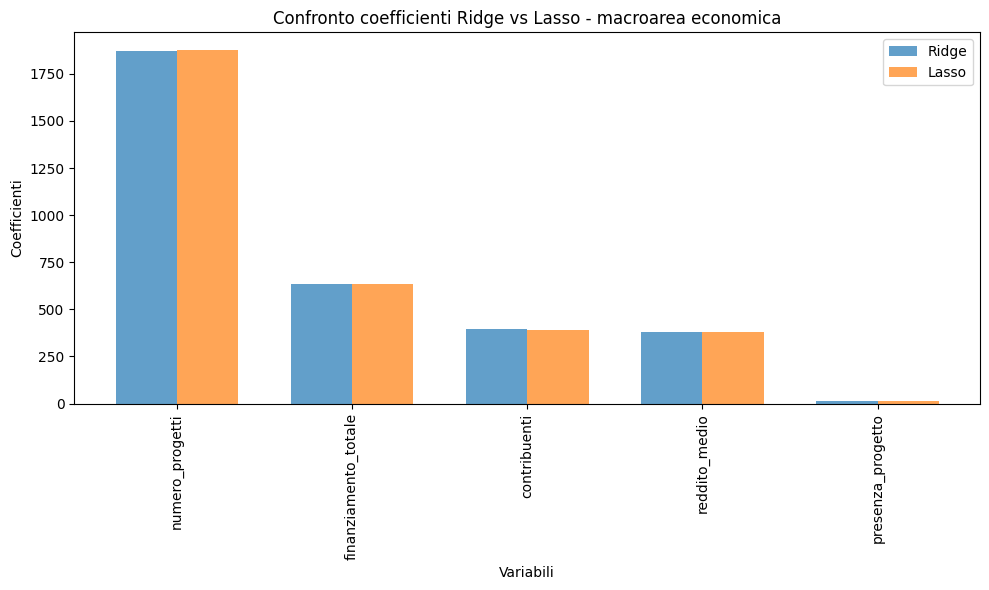

In [14]:
# Coefficienti già ordinati
ridge_plot = ridge1_coef.copy()
lasso_plot = lasso1_coef.reindex(ridge_plot.index)

variabili = ridge_plot.index
x = np.arange(len(variabili))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ridge_plot.values, width, label='Ridge', alpha=0.7)
plt.bar(x + width/2, lasso_plot.values, width, label='Lasso', alpha=0.7)

plt.xlabel('Variabili')
plt.ylabel('Coefficienti')
plt.title('Confronto coefficienti Ridge vs Lasso - macroarea economica')
plt.xticks(x, variabili, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

I coefficienti stimati dai modelli Ridge e Lasso risultano molto simili.
La variabile con maggiore peso è il numero di progetti finanziati,
seguita dal finanziamento totale e dal numero di contribuenti.
Questo suggerisce che la dimensione economica e gli investimenti pubblici
sono fattori rilevanti nella diffusione degli impianti fotovoltaici.

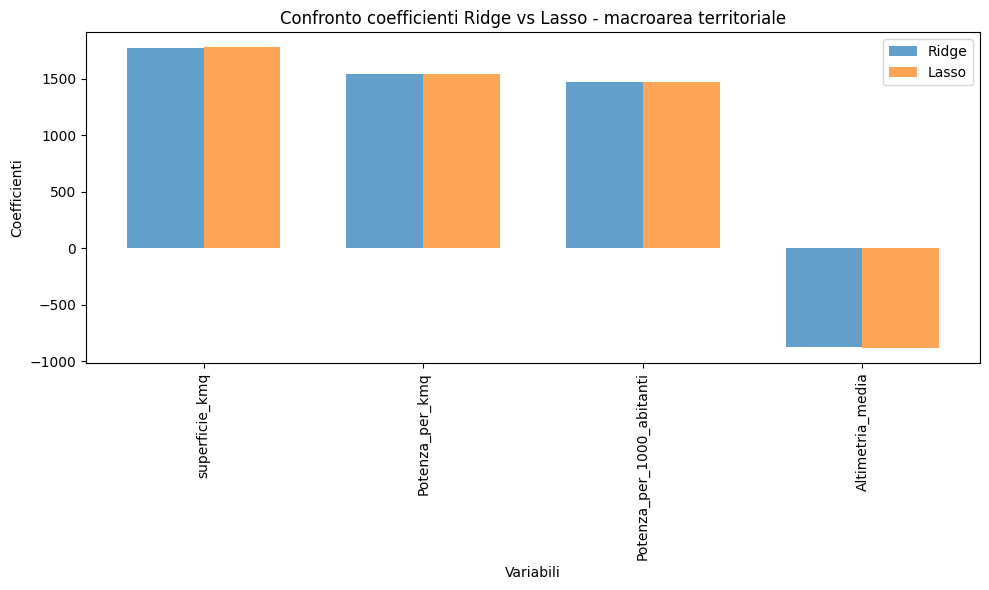

In [15]:
# Grafico coefficienti Ridge vs Lasso - macroarea territoriale

variabili = ridge2_coef.index
ridge_plot = ridge2_coef.values
lasso_plot = lasso2_coef.reindex(variabili).values

x = np.arange(len(variabili))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width / 2, ridge_plot, width, label='Ridge', alpha=0.7)
plt.bar(x + width / 2, lasso_plot, width, label='Lasso', alpha=0.7)

plt.xlabel('Variabili')
plt.ylabel('Coefficienti')
plt.title('Confronto coefficienti Ridge vs Lasso - macroarea territoriale')
plt.xticks(x, variabili, rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

I risultati dei modelli Ridge e Lasso sono coerenti tra loro.
La superficie comunale e gli indicatori di potenza installata
mostrano un effetto positivo, mentre l'altimetria media ha
un impatto negativo, suggerendo una minore diffusione del
fotovoltaico nelle aree più montane.

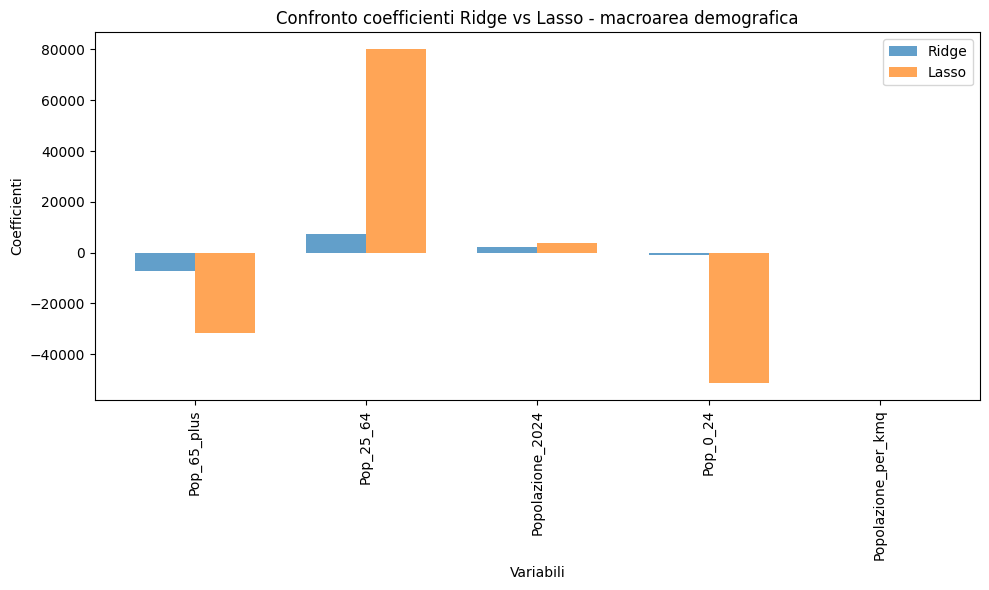

In [16]:
# Grafico coefficienti Ridge vs Lasso - macroarea demografica

variabili = ridge3_coef.index
ridge_plot = ridge3_coef.values
lasso_plot = lasso3_coef.reindex(variabili).values

x = np.arange(len(variabili))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width / 2, ridge_plot, width, label='Ridge', alpha=0.7)
plt.bar(x + width / 2, lasso_plot, width, label='Lasso', alpha=0.7)

plt.xlabel('Variabili')
plt.ylabel('Coefficienti')
plt.title('Confronto coefficienti Ridge vs Lasso - macroarea demografica')
plt.xticks(x, variabili, rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

Nella macroarea demografica emergono differenze più marcate
tra Ridge e Lasso. La fascia di popolazione 25–64 anni
risulta la più influente, mentre le altre fasce mostrano
un impatto più contenuto o negativo.

## 7. Modello di classificazione: presenza di impianti >30 kW

In questa sezione viene stimato un modello di regressione logistica
per analizzare i fattori associati alla presenza di impianti
fotovoltaici di potenza superiore a 30 kW nei comuni.

La variabile target è binaria:
- 1 = presenza di impianti >30 kW
- 0 = assenza di impianti >30 kW

I modelli vengono stimati separatamente per tre gruppi di variabili:
demografiche, economiche e territoriali, per valutare quale dimensione
spiega meglio la diffusione degli impianti di maggiore potenza.

In [17]:
# Creiamo una variabile binaria che indica la presenza di impianti >30 kW
df["has_30_plus"] = (df[">30 kW"] > 0).astype(int)

# Selezioniamo le variabili esplicative
X = df_demografico
y = df["has_30_plus"]

# Suddividiamo il dataset in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creiamo il modello di regressione logistica
logreg = LogisticRegression(max_iter=1000)

# Alleniamo il modello
logreg.fit(X_train, y_train)

# Predizione
y_pred = logreg.predict(X_test)

# Calcoliamo l'accuratezza
acc_demo = accuracy_score(y_test, y_pred)
print("Accuratezza modello demografico:", acc_demo)

print(f"Accuratezza del modello: {acc_demo:.2f}")

# Coefficienti del modello

coef_df = pd.Series(logreg.coef_[0], index=X.columns)
print(coef_df.sort_values(key=abs, ascending=False))

Accuratezza modello demografico: 0.6788990825688074
Accuratezza del modello: 0.68
Pop_25_64              0.003767
Pop_0_24              -0.002662
Pop_65_plus           -0.001806
Popolazione_2024      -0.000700
Popolazione_per_kmq   -0.000324
dtype: float64


In [18]:
X = df_economico
y = df["has_30_plus"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

acc_econ = accuracy_score(y_test, y_pred)
print("Accuratezza modello demografico:", acc_econ)

print("Accuratezza modello economico:", acc_econ)

coef_df = pd.Series(logreg.coef_[0], index=X.columns)
print(coef_df.sort_values(key=abs, ascending=False))

Accuratezza modello demografico: 0.6422018348623854
Accuratezza modello economico: 0.6422018348623854
numero_progetti         2.057400e-01
presenza_progetto       3.412373e-02
contribuenti            3.489445e-04
reddito_medio          -4.964844e-05
finanziamento_totale   -4.967240e-09
dtype: float64


In [19]:
X = df_territoriale
y = df["has_30_plus"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

acc_terr = accuracy_score(y_test, y_pred)
print("Accuratezza modello demografico:", acc_terr)

print("Accuratezza modello territoriale:", acc_terr)

coef_df = pd.Series(logreg.coef_[0], index=X.columns)
print(coef_df.sort_values(key=abs, ascending=False))

Accuratezza modello demografico: 0.8532110091743119
Accuratezza modello territoriale: 0.8532110091743119
Potenza_per_kmq              0.076510
superficie_kmq               0.050542
Potenza_per_1000_abitanti    0.011600
Altimetria_media            -0.000442
dtype: float64


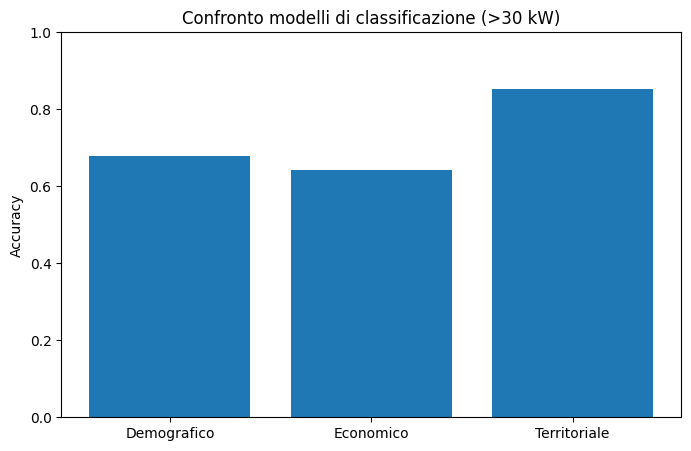

In [20]:
models = ["Demografico", "Economico", "Territoriale"]
scores = [acc_demo, acc_econ, acc_terr]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Confronto modelli di classificazione (>30 kW)")
plt.ylim(0,1)

plt.show()

### Interpretazione dei modelli di regressione logistica

I modelli sono stati stimati separatamente per tre gruppi di variabili: demografiche, economiche e territoriali.

I risultati indicano che:

- le variabili territoriali mostrano la maggiore capacità predittiva nella classificazione dei comuni con impianti fotovoltaici >30 kW (accuracy ≈ 0.85);
- le variabili demografiche ed economiche mostrano invece una capacità predittiva più moderata (accuracy tra 0.64 e 0.68).

Questo risultato suggerisce che la presenza di impianti fotovoltaici di maggiore potenza è più fortemente associata alle caratteristiche territoriali dei comuni (come superficie, densità di potenza installata e altimetria) rispetto ai soli fattori socio-economici o demografici.

## 8. Modelli Ridge e Lasso per classi di potenza degli impianti

In [21]:
# Target per le tre classi di potenza
potenza_targets = {
    "0-10 kW": df["0-10 kW"],
    "10-30 kW": df["10-30 kW"],
    ">30 kW": df[">30 kW"]
}


In [22]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Variabili finali combinate
variabili_combinate = [
    'Pop_0_24', 'Pop_25_64', 'Pop_65_plus',
    'superficie_kmq', 'Altimetria_media', 'Potenza_per_kmq',
    'numero_progetti', 'contribuenti', 'reddito_medio'
]

X_combinato = X_clean[variabili_combinate]

# Dizionari per salvare i risultati
mse_ridge_comb = {}
mse_lasso_comb = {}
coefs_ridge_comb = {}
coefs_lasso_comb = {}

# Loop su ogni classe target
for label, y in potenza_targets.items():
    print(f"\n====== MODELLO COMBINATO – Classe: {label} ======")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_combinato, y, test_size=0.2, random_state=42)

    # Ridge
    ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    ridge_pipe.fit(X_train, y_train)
    y_pred_ridge = ridge_pipe.predict(X_test)
    mse_ridge_comb[label] = mean_squared_error(y_test, y_pred_ridge)
    print(f"Ridge MSE (combinato): {mse_ridge_comb[label]}")

    # Lasso
    lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
    lasso_pipe.fit(X_train, y_train)
    y_pred_lasso = lasso_pipe.predict(X_test)
    mse_lasso_comb[label] = mean_squared_error(y_test, y_pred_lasso)
    print(f"Lasso MSE (combinato): {mse_lasso_comb[label]}")



====== MODELLO COMBINATO – Classe: 0-10 kW ======
Ridge MSE (combinato): 1195.673451362588
Lasso MSE (combinato): 896.7068445681584

====== MODELLO COMBINATO – Classe: 10-30 kW ======
Ridge MSE (combinato): 26.454584740488166
Lasso MSE (combinato): 27.9220574322811

====== MODELLO COMBINATO – Classe: >30 kW ======
Ridge MSE (combinato): 9.505020771617914
Lasso MSE (combinato): 9.7100175017127


### COMMENTO - Modello combinato finale

Il modello combinato finale utilizza le variabili più rilevanti emerse
dalle analisi precedenti e le standardizza prima della stima di Ridge e Lasso.

I risultati mostrano che:
 - nella classe 0–10 kW il modello Lasso ottiene un MSE più basso del Ridge;
 - nella classe 10–30 kW i due modelli hanno performance molto simili;
 - nella classe >30 kW Ridge e Lasso risultano ancora vicini, con un lieve vantaggio del Ridge.

 Nel complesso, l'integrazione di variabili demografiche, territoriali ed economiche
 produce un modello più equilibrato e interpretabile rispetto alle analisi separate
 per singola macroarea.

##  9. Modelli classificativi e individuazione dei comuni con potenziale fotovoltaico (>30 kW)

In [23]:
# Target binario: 1 se il comune ospita almeno un impianto nella fascia di potenza, 0 altrimenti
df['has_0_10'] = (df['0-10 kW'] > 0).astype(int)
df['has_10_30'] = (df['10-30 kW'] > 0).astype(int)
df['has_30_plus'] = (df['>30 kW'] > 0).astype(int)


In [24]:
# Target binari
target_classi = {
    '0-10 kW': df['has_0_10'],
    '10-30 kW': df['has_10_30'],
    '>30 kW': df['has_30_plus']
}

# Variabili esplicative combinate (stesse del modello ibrido)
X_clf = X_clean[[
    'Pop_0_24', 'Pop_25_64', 'Pop_65_plus',
    'superficie_kmq', 'Altimetria_media', 'Potenza_per_kmq',
    'numero_progetti', 'contribuenti', 'reddito_medio'
]]

# Loop su ogni modello binario
for label, y in target_classi.items():
    print(f"\n====== CLASSIFICATORE – Presenza impianti {label} ======")

    X_train, X_test, y_train, y_test = train_test_split(X_clf, y, test_size=0.2, random_state=42)

    clf_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf_pipe.fit(X_train, y_train)

    y_pred = clf_pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuratezza: {acc:.3f}")

    print("Classification report:")
    print(classification_report(y_test, y_pred))

    print("Matrice di confusione:")
    print(confusion_matrix(y_test, y_pred))



====== CLASSIFICATORE – Presenza impianti 0-10 kW ======
Accuratezza: 1.000
Classification report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       109

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109

Matrice di confusione:
[[109]]

====== CLASSIFICATORE – Presenza impianti 10-30 kW ======
Accuratezza: 0.908
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.09      0.17        11
           1       0.91      1.00      0.95        98

    accuracy                           0.91       109
   macro avg       0.95      0.55      0.56       109
weighted avg       0.92      0.91      0.87       109

Matrice di confusione:
[[ 1 10]
 [ 0 98]]

====== CLASSIFICATORE – Presenza impianti >30 kW ======
Accuratezza: 0.752
Classification report:
              precision    

### Commento ai modelli classificativi

Sono stati stimati tre modelli di regressione logistica per classificare la presenza di impianti fotovoltaici nelle diverse classi di potenza (0–10 kW, 10–30 kW e >30 kW).
L’obiettivo è valutare la capacità delle variabili territoriali, demografiche ed economiche di spiegare la presenza di impianti nelle diverse fasce di potenza.

**Classe 0–10 kW**  
Il modello mostra un’accuratezza pari a 1.00, ma il risultato è poco informativo: nel dataset tutti i comuni presentano almeno un impianto in questa fascia, quindi il classificatore predice sempre la classe positiva.

**Classe 10–30 kW**  
Il modello raggiunge una buona accuratezza complessiva (~0.91), ma le metriche mostrano un forte sbilanciamento tra le classi. In particolare il modello identifica bene i comuni con impianti, mentre fatica a riconoscere quelli senza impianti.

**Classe >30 kW**  
Questa fascia risulta la più interessante dal punto di vista analitico, perché la distribuzione tra presenza e assenza di impianti è più equilibrata. Per questo motivo gli approfondimenti successivi si concentrano sulla classe >30 kW.


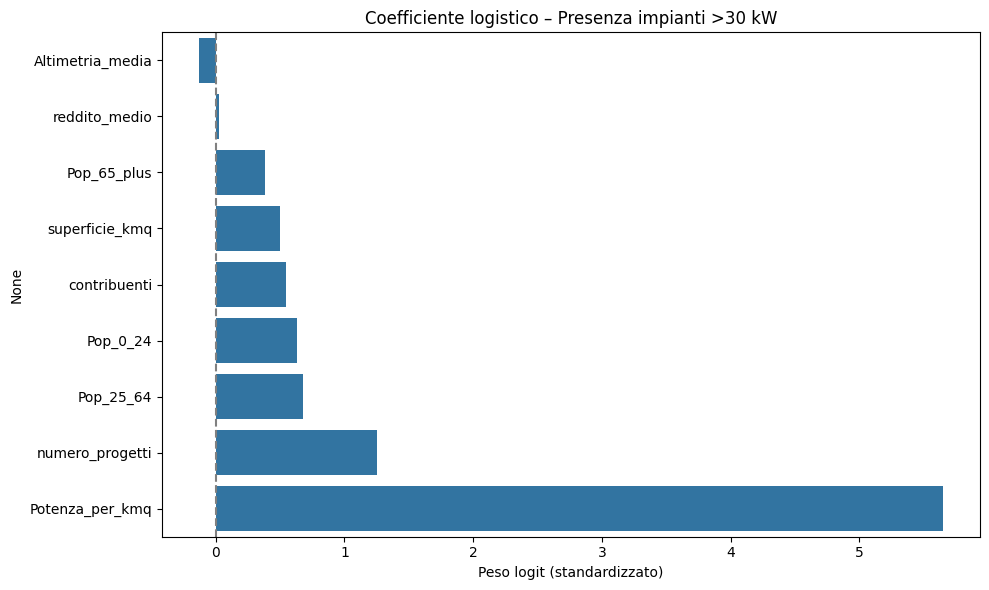

In [25]:
# Modello classificativo >30 kW con Logistic Regression (standardizzato)
# Modello su tutta la base (non train/test per ora, vogliamo leggere i pesi)
X_std = StandardScaler().fit_transform(X_clf)
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_std, df['has_30_plus'])

# Coefficienti
coefs = pd.Series(logit_model.coef_[0], index=X_clf.columns).sort_values()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=coefs.values, y=coefs.index)
plt.title('Coefficiente logistico – Presenza impianti >30 kW')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Peso logit (standardizzato)')
plt.tight_layout()
plt.show()


### Interpretazione dei coefficienti – Modello >30 kW

È stata stimata una regressione logistica per analizzare quali caratteristiche territoriali e socio-economiche influenzano la presenza di impianti fotovoltaici di potenza superiore a 30 kW.

Le variabili esplicative sono state standardizzate tramite StandardScaler per rendere confrontabili i coefficienti del modello.

Il grafico mostra il peso logistico di ciascuna variabile. I coefficienti positivi indicano un aumento della probabilità che un comune ospiti impianti di questa classe di potenza, mentre quelli negativi indicano un effetto opposto.

Dai risultati emerge che alcune caratteristiche territoriali, come la superficie comunale, tendono ad aumentare la probabilità di presenza di impianti >30 kW, mentre fattori morfologici come l’altimetria media risultano associati negativamente alla presenza di impianti di grande scala.

Questa analisi consente quindi di individuare quali caratteristiche del territorio sono maggiormente associate alla diffusione di impianti fotovoltaici di scala medio-grande.

### Individuazione dei comuni con alta probabilità di impianti >30 kW

In [26]:
# Riprendiamo modello già addestrato
proba = logit_model.predict_proba(X_std)[:, 1]  # Probabilità classe 1

# Aggiungiamo al DataFrame
df['proba_>30kW'] = proba

# Filtriamo i comuni che NON hanno impianti >30kW
# ma hanno una probabilità ALTA di averli secondo il modello
target_comuni = df[(df['has_30_plus'] == 0) & (df['proba_>30kW'] > 0.6)]

# Mostriamo i più promettenti
target_comuni = target_comuni.sort_values(by='proba_>30kW', ascending=False)

# Visualizzazione rapida
target_comuni[['Comune', 'proba_>30kW']].head(20)


,Comune,proba_>30kW
399,SAN GIORGIO LA MOLARA,0.978992
358,PROCIDA,0.889465
142,CESA,0.883165
531,VICO EQUENSE,0.848938
36,BAIA E LATINA,0.832992
67,CALVIZZANO,0.820309
461,SANZA,0.818246
493,SUCCIVO,0.815459
63,CALITRI,0.748431
329,PIETRAMELARA,0.730191


Dopo aver valutato le prestazioni dei modelli classificativi, il modello logistico per la classe >30 kW viene utilizzato per stimare la probabilità di presenza di impianti in tutti i comuni del dataset.

### Comuni da attenzionare – Impianti >30 kW

Utilizzando il modello di regressione logistica stimato in precedenza, è stata calcolata per ogni comune la probabilità di presenza di impianti fotovoltaici di potenza superiore a 30 kW.

Questa probabilità rappresenta una stima della vocazione del territorio ad ospitare impianti di questa classe di potenza, sulla base delle caratteristiche territoriali e socio-economiche considerate nel modello.

Successivamente sono stati selezionati i comuni che attualmente non presentano impianti >30 kW ma che mostrano una probabilità elevata di ospitarli secondo il modello (proba > 0.6).

Questi comuni rappresentano quindi territori con potenziale fotovoltaico non ancora sfruttato e possono essere considerati aree prioritarie per future politiche di sviluppo o per interventi di pianificazione energetica.


====== RANDOM FOREST – Classe >30 kW ======
Accuracy: 0.8348623853211009
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        42
           1       0.88      0.85      0.86        67

    accuracy                           0.83       109
   macro avg       0.82      0.83      0.83       109
weighted avg       0.84      0.83      0.84       109

Matrice di Confusione:
[[34  8]
 [10 57]]


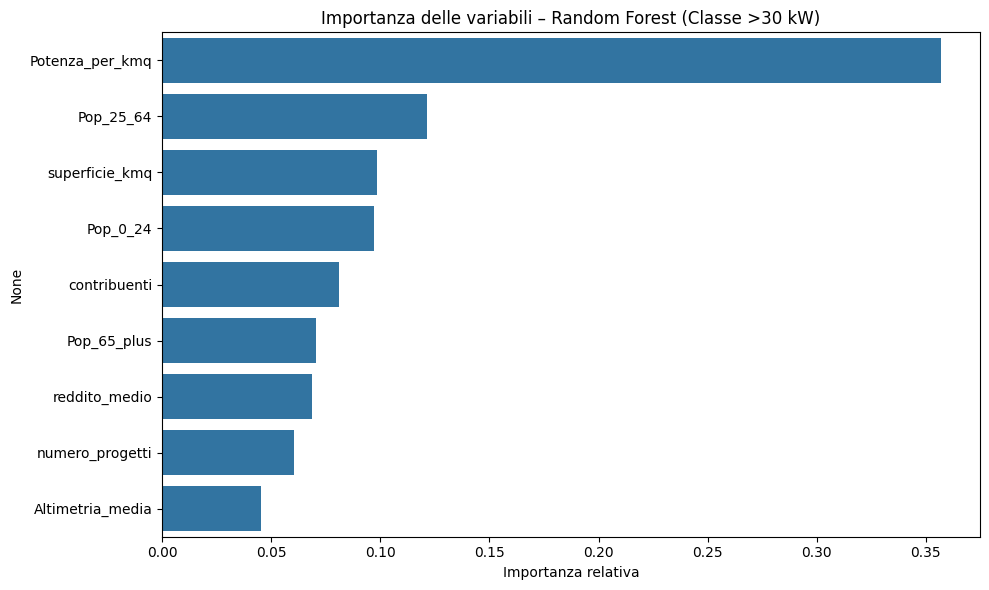

In [27]:

# Dataset: stesso X_clf standardizzato, stessa variabile target
X_train, X_test, y_train, y_test = train_test_split(X_clf, df['has_30_plus'], test_size=0.2, random_state=42)

# Modello Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predizioni
y_pred_rf = rf.predict(X_test)

# Risultati
print("====== RANDOM FOREST – Classe >30 kW ======")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred_rf))

# Importanza variabili
importances_rf = pd.Series(rf.feature_importances_, index=X_clf.columns).sort_values(ascending=False)

# Visualizzazione importanza
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_rf.values, y=importances_rf.index)
plt.title('Importanza delle variabili – Random Forest (Classe >30 kW)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()


# COMMENTO – Random Forest Classificatore (>30 kW)

È stato costruito un modello classificativo Random Forest per prevedere la presenza
di impianti fotovoltaici con potenza superiore a 30 kW.

Il modello mostra una buona capacità predittiva:

- Accuracy: ~0.83
- Recall classe 1 (presenza impianti): ~0.85
- Recall classe 0 (assenza impianti): ~0.79

A differenza della regressione logistica, la Random Forest è in grado di catturare
relazioni non lineari tra le variabili.

Le variabili più importanti secondo il modello risultano:

- Potenza_per_kmq (la più influente)
- Pop_25_64 e Pop_0_24 (componenti demografiche)
- superficie_kmq e contributi (dimensione territoriale e fattori economici)

Il modello si dimostra quindi utile per individuare territori con caratteristiche
compatibili con la presenza di impianti fotovoltaici di scala medio-grande.

In [28]:
# Predizione delle probabilità e classi su tutto il dataset
y_pred_rf_all = rf.predict(X_clf)  # predizione su tutto il df, non solo test

# Aggiungiamo la predizione al dataframe
df['rf_pred_>30kW'] = y_pred_rf_all

# Filtriamo i comuni che NON hanno impianti >30 kW ma sono stati classificati come 1 (presenza attesa)
rf_target = df[(df['has_30_plus'] == 0) & (df['rf_pred_>30kW'] == 1)]

# Ordinamento opzionale per contribuire alla lettura
rf_target = rf_target.sort_values(by='Potenza_per_kmq', ascending=False)

# Visualizza i primi comuni suggeriti
rf_target[['Comune', 'Potenza_per_kmq', 'rf_pred_>30kW']].head(20)


,Comune,Potenza_per_kmq,rf_pred_>30kW
101,CASAPESENNA,54.705250,1
82,CAPRIGLIA IRPINA,26.979401,1
180,FONTANAROSA,14.895019,1
72,CAMPOLI DEL MONTE TABURNO,13.496236,1
220,LAPIO,12.025557,1
494,SUMMONTE,8.486007,1
137,CERASO,5.059206,1
63,CALITRI,3.383752,1


### CONFRONTO: Logistic Regression vs Random Forest


È stato effettuato un confronto tra i comuni suggeriti dalla regressione logistica
(probabilità > 0.6 di avere impianti >30 kW) e quelli classificati positivamente
dalla Random Forest (classe 1, ma attualmente senza impianti).

- L’unico comune condiviso da entrambi i modelli è: CALITRI
 rappresenta una conferma trasversale, suggerendo un territorio prioritario per eventuali approfondimenti

Gli altri comuni suggeriti divergono tra i due approcci:
- La regressione logistica seleziona comuni in cui le variabili territoriali
e socio-economiche mostrano una relazione lineare con la presenza degli impianti.

- La Random Forest evidenzia invece territori che emergono da combinazioni
più complesse e non lineari delle variabili.

### Conclusione:
Utilizzare entrambi i modelli in parallelo consente di:
- Rafforzare la selezione dei comuni in comune
- Espandere la lista dei territori potenzialmente adatti grazie a logiche diverse

Questo approccio consente di individuare territori con potenziale
fotovoltaico non ancora sfruttato e rappresenta uno strumento utile
per supportare decisioni di pianificazione energetica del territorio.

## 10. Cluster Analysis e politiche mirate

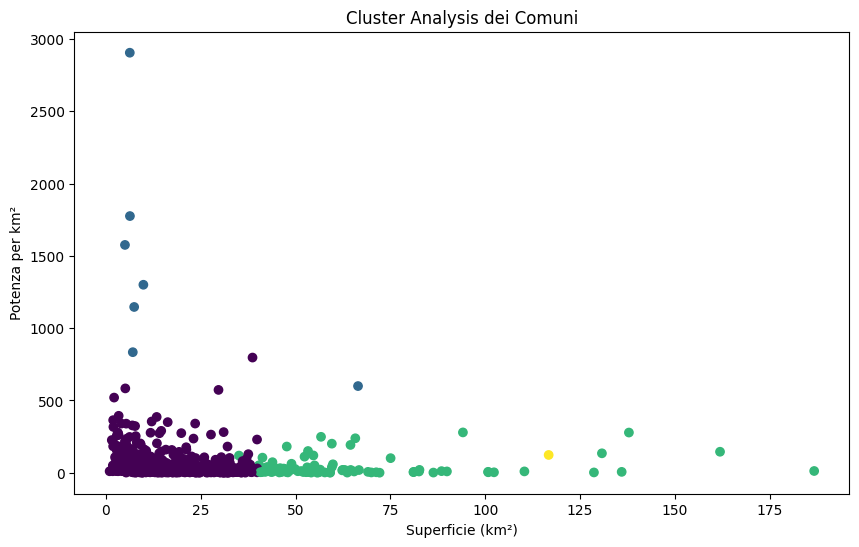

In [29]:
# Selezioniamo le variabili per il clustering (es. senza variabili categoriali)
X_cluster = df[['Popolazione_2024', 'superficie_kmq', 'Potenza_per_kmq', 'Potenza_per_1000_abitanti']]

# Standardizzazione delle variabili
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Applichiamo KMeans con 4 cluster, scelti come soluzione iniziale da interpretare
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) 
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualizzazione dei cluster
plt.figure(figsize=(10, 6))
plt.scatter(df['superficie_kmq'], df['Potenza_per_kmq'], c=df['Cluster'], cmap='viridis')
plt.title('Cluster Analysis dei Comuni')
plt.xlabel('Superficie (km²)')
plt.ylabel('Potenza per km²')
plt.show()







In [30]:
# Esploriamo i comuni per ciascun cluster
df_clusters = df[['Comune', 'Cluster', 'superficie_kmq', 'Potenza_per_kmq', 'Popolazione_2024']]

for i in sorted(df['Cluster'].unique()):
    print(f"\n===== Cluster {i} =====")
    display(
        df_clusters[df_clusters['Cluster'] == i]
        .sort_values(by='Potenza_per_kmq', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )


===== Cluster 0 =====


,Comune,Cluster,superficie_kmq,Potenza_per_kmq,Popolazione_2024
0,NOLA,0,38.6410,796.591186,33843
1,ARZANO,0,5.1033,583.263771,31938
2,MARCIANISE,0,29.6734,572.824820,38292
3,FRATTAMINORE,0,2.1495,519.767388,15367
4,CASANDRINO,0,3.3558,393.754097,13069
5,PASTORANO,0,13.3728,385.842157,2871
6,PORTICO DI CASERTA,0,1.9037,363.675999,7722
7,CASORIA,0,12.0574,354.316851,73814
8,RIARDO,0,16.2810,350.025797,2216
9,VITULAZIO,0,23.5209,340.145998,7696



===== Cluster 1 =====


,Comune,Cluster,superficie_kmq,Potenza_per_kmq,Popolazione_2024
0,CARINARO,1,6.2879,2904.777430,7077
1,TEVEROLA,1,6.3228,1775.170810,14962
2,SAN NICOLA LA STRADA,1,5.0124,1575.554625,22071
3,GRICIGNANO DI AVERSA,1,9.8682,1300.072962,12900
4,STRIANO,1,7.4396,1146.471584,9028
5,SANT'ANDREA DI CONZA,1,7.0775,833.768986,1402
6,SERRE,1,66.4581,599.490657,3690



===== Cluster 2 =====


,Comune,Cluster,superficie_kmq,Potenza_per_kmq,Popolazione_2024
0,GIUGLIANO IN CAMPANIA,2,94.1139,278.896741,124209
1,EBOLI,2,137.8774,277.971082,37581
2,BATTIPAGLIA,2,56.7024,248.427051,49496
3,BUCCINO,2,65.7417,238.321948,4516
4,SALERNO,2,59.5558,201.068578,126715
5,ALIFE,2,64.4711,192.304304,7389
6,CAPUA,2,47.6713,181.235880,17773
7,CASERTA,2,53.2717,150.267778,72699
8,SESSA AURUNCA,2,161.8987,145.187701,20209
9,BENEVENTO,2,130.7616,134.405437,56048



===== Cluster 3 =====


,Comune,Cluster,superficie_kmq,Potenza_per_kmq,Popolazione_2024
0,NAPOLI,3,116.7187,122.955619,913704


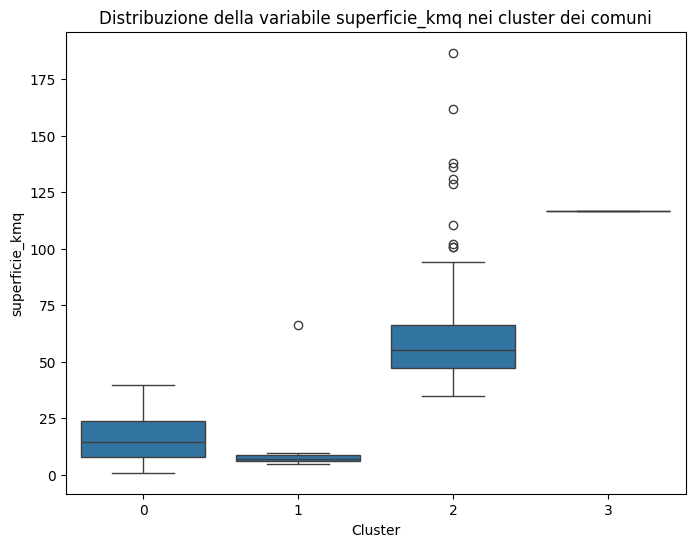

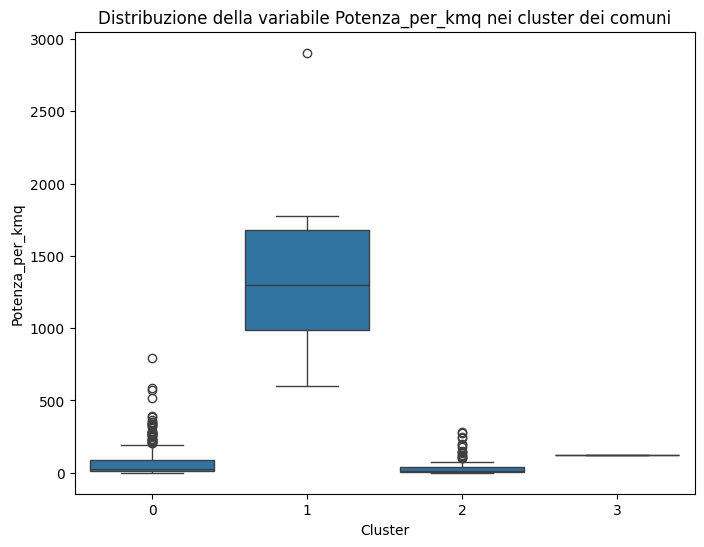

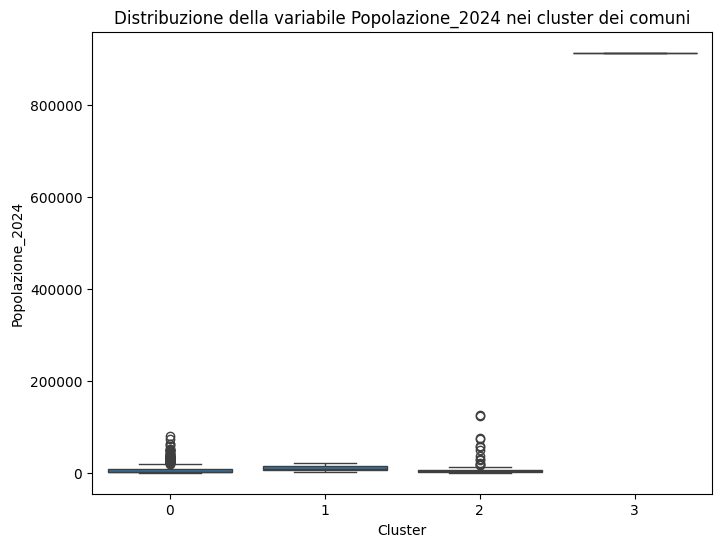

In [31]:
# Analisi della distribuzione delle variabili per ogni cluster
variables_to_explore = ['superficie_kmq', 'Potenza_per_kmq', 'Popolazione_2024']

# Creazione dei grafici di distribuzione per ogni variabile
for var in variables_to_explore:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cluster', y=var, data=df)
    plt.title(f'Distribuzione della variabile {var} nei cluster dei comuni')
    plt.show()


In [32]:

# Analisi descrittiva delle variabili chiave per ciascun cluster
cluster_description = df.groupby("Cluster")[["superficie_kmq", "Popolazione_2024", "Potenza_per_kmq", "Potenza_per_1000_abitanti"]].agg(["mean", "std", "median"])
display(cluster_description)


superficie_kmq                      Popolazione_2024                \
                  mean        std    median             mean           std   
Cluster                                                                      
0            16.552075  10.213947   14.5781      7880.287330  12073.782104   
1            15.495214  22.521941    7.0775     10161.428571   7092.114021   
2            63.767391  27.394533   55.1094     11318.776596  22278.980767   
3           116.718700        NaN  116.7187    913704.000000           NaN   

                  Potenza_per_kmq                           \
           median            mean         std       median   
Cluster                                                      
0          2626.5       67.026605   95.387127    29.098499   
1          9028.0     1447.901008  758.898431  1300.072962   
2          3803.0       40.778002   64.730641    13.238806   
3        913704.0      122.955619         NaN   122.955619   

        Potenza_per_1000_abitanti                           
                             mean          std      median  
Cluster                                                     
0                      188.542168   298.344947  102.333284  
1                     2947.738166  3712.603609  994.525581  
2                      327.531326   492.433873  164.988043  
3                       15.706640          NaN   15.706640

In [33]:

# Numero di comuni per ciascun cluster
cluster_counts = df["Cluster"].value_counts().sort_index()
print("Numero di comuni per cluster:\n", cluster_counts)


Numero di comuni per cluster:
 Cluster
0    442
1      7
2     94
3      1
Name: count, dtype: int64



## Commento sull'Analisi dei Cluster

L’analisi dei cluster ha identificato 4 gruppi distinti di comuni sulla base delle variabili: superficie, popolazione, potenza per km² e potenza per 1000 abitanti.

Cluster 0: Raccoglie la maggior parte dei comuni (442). Rappresenta il profilo medio del territorio campano, con valori relativamente bilanciati tra superficie, popolazione e sviluppo fotovoltaico.

Cluster 1: Include un piccolo gruppo di comuni (7) caratterizzati da una densità fotovoltaica molto elevata. I valori di Potenza_per_kmq e Potenza_per_1000_abitanti risultano significativamente superiori alla media regionale. Questi comuni rappresentano casi di sviluppo fotovoltaico particolarmente intensivo.

Cluster 2: Comprende 94 comuni con superficie mediamente più elevata ma livelli relativamente contenuti di densità fotovoltaica. Questo cluster può rappresentare territori con potenziale di sviluppo energetico ancora non pienamente sfruttato.

Cluster 3: È composto da un solo comune, che emerge come outlier rispetto agli altri a causa delle sue dimensioni demografiche ed economiche. In questo caso si tratta della città di Napoli, che presenta caratteristiche strutturali molto diverse rispetto al resto dei comuni della regione.